In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid") 

In [131]:
# loading the dataset 
# Dataset link: https://www.kaggle.com/datasets/ealaxi/paysim1 
df = pd.read_csv("PS_20174392719_1491204439457_log.csv", nrows=10000)  #only a sample of the first 10000 rows
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  object 
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  object 
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  object 
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 859.5+ KB


In [133]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [109]:
# df = df.drop(columns=["isFlaggedFraud"])
# df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [134]:
df["isFraud"].value_counts()

isFraud
0    9932
1      68
Name: count, dtype: int64

In [135]:
df.isnull().sum().sum()

np.int64(0)

In [136]:
df.shape

(10000, 11)

In [137]:
#percentage of the frauds
round((df["isFraud"].value_counts()[1]/ df.shape[0]) *100,1)

np.float64(0.7)

Text(0, 0.5, 'Count')

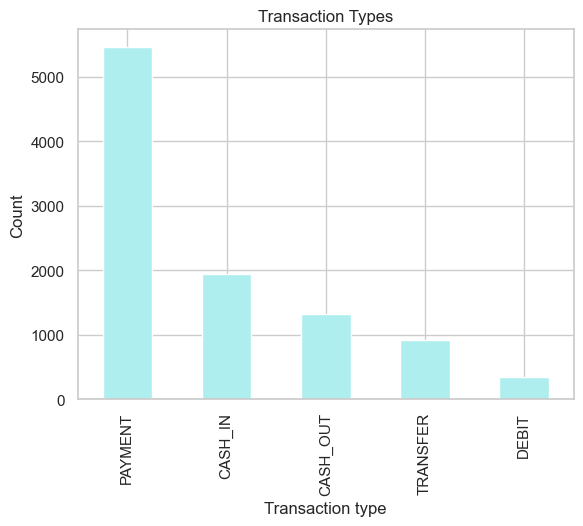

In [138]:
df["type"].value_counts().plot(kind="bar",title="Transaction Types", color = "paleturquoise")
plt.xlabel("Transaction type")
plt.ylabel("Count")

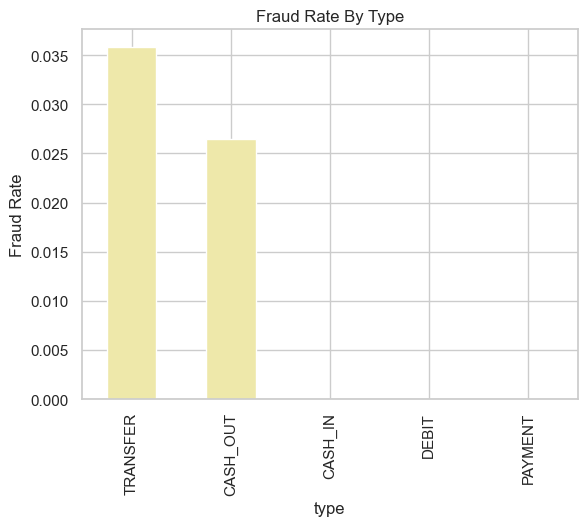

In [139]:
#fraud rates by types 
fraud_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_type.plot(kind="bar",title="Fraud Rate By Type", color="palegoldenrod")
plt.ylabel("Fraud Rate")
plt.show()

In [47]:
#So red flags ==> Transfer and Cash_out 

In [140]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]
fraud_types["type"].value_counts()

type
CASH_OUT    1321
TRANSFER     921
Name: count, dtype: int64

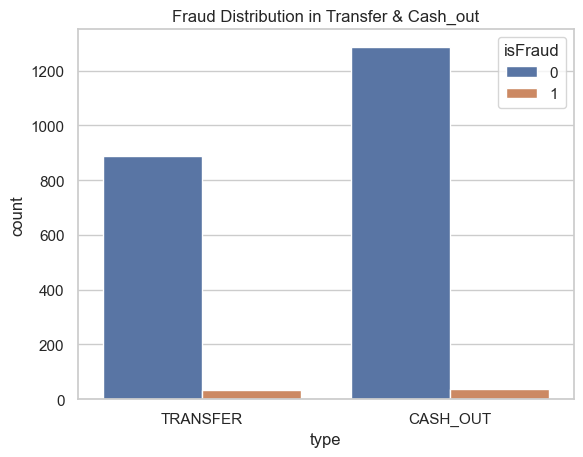

In [141]:
sns.countplot(data=fraud_types, x = "type", hue = "isFraud")
plt.title("Fraud Distribution in Transfer & Cash_out")
plt.show()

In [142]:
# correlaltion matrix 
corr = df[["amount","oldbalanceOrg","newbalanceOrig", "oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [143]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.123194,0.089860,0.347842,0.412863,0.133586
oldbalanceOrg,0.123194,1.000000,0.996727,0.228128,0.198181,-0.012607
newbalanceOrig,0.089860,0.996727,1.000000,0.236321,0.202469,-0.033084
oldbalanceDest,0.347842,0.228128,0.236321,1.000000,0.944481,-0.021004
newbalanceDest,0.412863,0.198181,0.202469,0.944481,1.000000,-0.010887
isFraud,0.133586,-0.012607,-0.033084,-0.021004,-0.010887,1.000000


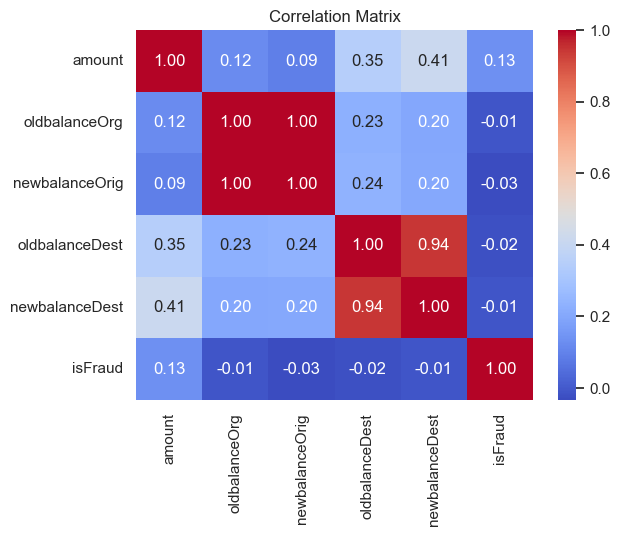

In [144]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix") 
plt.show()

In [145]:
df["amount"].describe().astype(int)

count       10000
mean       103546
std        266307
min             2
25%          4397
50%         12858
75%        114382
max      10000000
Name: amount, dtype: int64

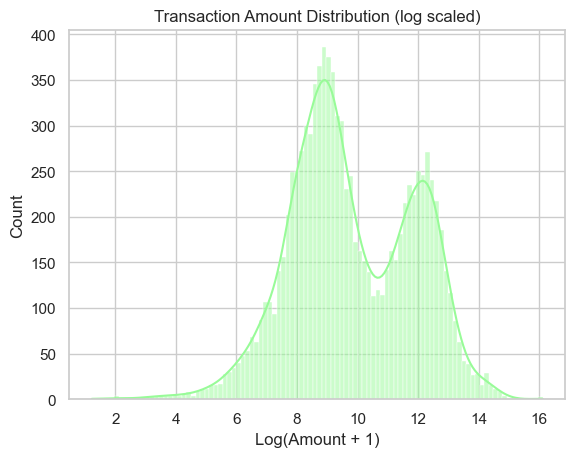

In [146]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "palegreen")
plt.title("Transaction Amount Distribution (log scaled)")
plt.xlabel("Log(Amount + 1)")
plt.show()

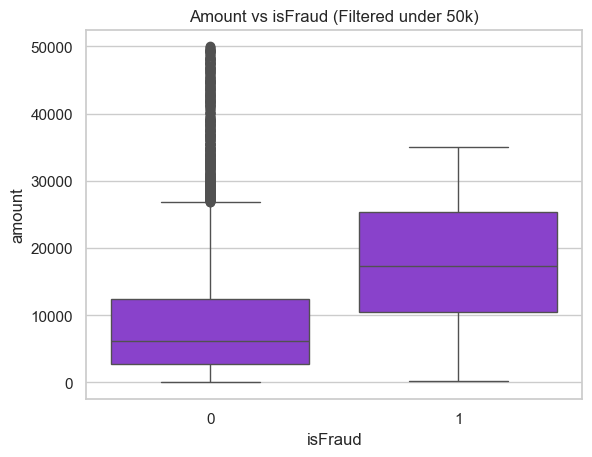

In [147]:
sns.boxplot(data=df[df["amount"] <50000], x = "isFraud", y="amount", color = "blueviolet")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [56]:
#Fraud is usually higher amounts 

In [148]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["newbalanceDest"]

In [149]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1929)

In [150]:
(df["balanceDiffDest"] < 0).sum()

np.int64(0)

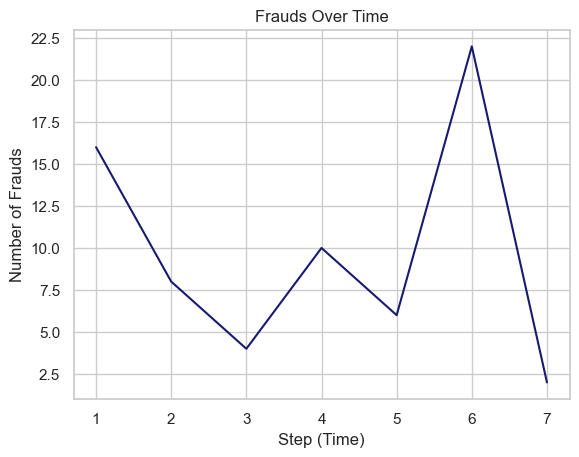

In [151]:
frauds_per_step = df[df["isFraud"] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per Step", color = "midnightblue")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds") 
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [152]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C299358529     1
C1231006815    1
C1666544295    1
C1305486145    1
C840083671     1
C2048537720    1
C90045638      1
C154988899     1
C1912850431    1
C1265012928    1
Name: count, dtype: int64

In [153]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C985934102     62
C1590550415    52
C1286084959    50
C1899073220    44
C1782113663    43
C451111351     43
C977993101     43
C2083562754    41
C1816757085    40
C1789550256    40
Name: count, dtype: int64

In [154]:
fraud_users = df[df["isFraud"] ==1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [155]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"]==0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]
zero_after_transfer.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,0.0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,0.0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,0.0
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,0.0


In [156]:
len(zero_after_transfer)

734

In [157]:
#now onto feature selection
from sklearn.model_selection import train_test_split #for splitting our data into training and testing sets
from sklearn.preprocessing import StandardScaler #for scaling data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix #for model evaluation 
from sklearn.pipeline import Pipeline #for training the model and doing the transformation operations
from sklearn.compose import ColumnTransformer #other two for data transformation
from sklearn.preprocessing import OneHotEncoder #0s and 1s

In [158]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [159]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis = 1)

In [160]:
df_model.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [161]:
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [162]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis=1)

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y) #30% for testing and 70% for training

In [164]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder = "drop"
)

In [165]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])

In [166]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [178]:
y_pred= pipeline.predict(X_test)

In [179]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92      2980
           1       0.04      0.95      0.08        20

    accuracy                           0.85      3000
   macro avg       0.52      0.90      0.50      3000
weighted avg       0.99      0.85      0.91      3000



In [180]:
confusion_matrix(y_test, y_pred)

array([[2532,  448],
       [   1,   19]])

In [181]:
pipeline.score(X_test, y_test)

0.8503333333333334